# Лабораторная работа №3
## Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей

### Цель работы
Изучить способы подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

### Постановка задания
1. Выбрать датасет для задачи классификации или регрессии.
2. При необходимости обработать пропуски и категориальные признаки.
3. Разделить выборку на обучающую и тестовую через train_test_split.
4. Обучить базовую модель KNN с произвольным K и оценить качество.
5. Подобрать гиперпараметры с GridSearchCV и RandomizedSearchCV с кросс-валидацией (минимум 2 стратегии).
6. Сравнить качество базовой и оптимальных моделей.

In [33]:
# 1. Подготовка окружения и путей к данным
from pathlib import Path
import io
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

project_dir = Path.cwd()
artifacts_dir = project_dir / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

print("Рабочая директория:", project_dir)
print("Папка для артефактов:", artifacts_dir)

Рабочая директория: d:\6 сем\тмо\lab3
Папка для артефактов: d:\6 сем\тмо\lab3\artifacts


In [34]:
# 2. Загрузка нового датасета (Wine, не breast cancer)
def load_wine_dataset():
    wine = load_wine(as_frame=True)
    df_local = wine.frame.copy()
    df_local = df_local.rename(columns={"target": "failure"})
    return df_local, "classification", "sklearn Wine"


df, task_type, dataset_name = load_wine_dataset()

print("Выбранный датасет:", dataset_name)
print("Тип задачи:", task_type)
print("Размерность:", df.shape)
print("Целевая переменная:", "failure")

Выбранный датасет: sklearn Wine
Тип задачи: classification
Размерность: (178, 14)
Целевая переменная: failure


### Пояснение к датасету
Используется датасет **Wine** из `sklearn`.

Что показывает датасет:
- Каждый объект — образец вина.
- Признаки — физико-химические характеристики (например, alcohol, flavanoids и др.).
- Целевая переменная `failure` (переименована из `target`) — класс вина: 0, 1 или 2.

То есть задача в этой лабораторной — **многоклассовая классификация**: по признакам определить класс вина.

### Какие способы использованы в работе

#### Способ 1: Базовая модель KNN
- Обучение и оценка KNN с фиксированным `K = 5`.

#### Способ 2: Разбиение выборки
- `train_test_split` со стратификацией классов (`stratify=y`).

#### Способ 3: Кросс-валидация (стратегия 1)
- `StratifiedKFold (5 фолдов)`.

#### Способ 4: Кросс-валидация (стратегия 2)
- `RepeatedStratifiedKFold (5x3)`.

#### Способ 5: Подбор гиперпараметров (метод 1)
- `GridSearchCV` (полный перебор сетки параметров).

#### Способ 6: Подбор гиперпараметров (метод 2)
- `RandomizedSearchCV` (случайный поиск параметров).

Итого: **алгоритм один (KNN)**, но применены **разные способы валидации и настройки модели**.

In [35]:
# 3. Первичный анализ данных и проверка задачи
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

print("\nОписательная статистика (числовые признаки):")
display(df.describe(include=[np.number]).T.head(15))

missing = df.isna().sum().sort_values(ascending=False)
print("\nТоп-15 признаков по числу пропусков:")
display(missing.head(15).to_frame("missing_count"))

print("\nРаспределение целевой переменной:")
display(df["failure"].value_counts(dropna=False).to_frame("count"))

Первые 5 строк:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,failure
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



Топ-15 признаков по числу пропусков:


,missing_count
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Распределение целевой переменной:


,count
failure,
1,71
0,59
2,48


C:\Users\timur\AppData\Local\Temp\ipykernel_10192\2879508505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["failure"].astype(str), palette="Set2")


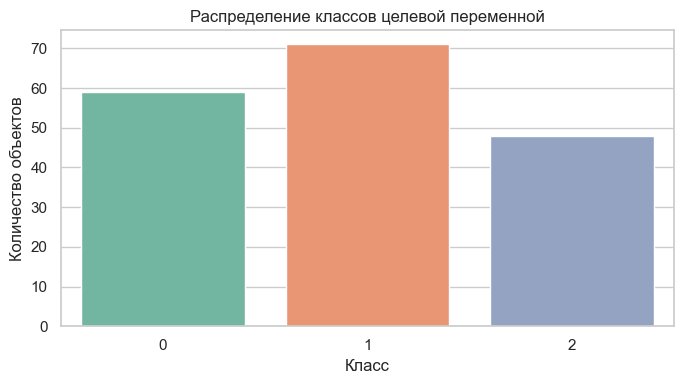

In [36]:
# 3.1 Визуализация распределения целевой переменной
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=df["failure"].astype(str), palette="Set2")
ax.set_title("Распределение классов целевой переменной")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество объектов")
plt.tight_layout()
plt.savefig(artifacts_dir / "class_distribution.png", dpi=150)
plt.show()

**Подпись к рисунку:** Распределение классов показывает баланс (или дисбаланс) целевой переменной failure. Если один класс сильно преобладает, это может завышать accuracy, поэтому далее дополнительно используются F1 и стратифицированная кросс-валидация.

In [37]:
# 4. Предобработка: пропуски, кодирование категориальных признаков, масштабирование
TARGET_COL = "failure"
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

y = pd.to_numeric(y, errors="coerce").fillna(0).astype(int)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")

Числовых признаков: 13
Категориальных признаков: 0


In [38]:
# 5. Разделение выборки через train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Доли классов в train:")
print(y_train.value_counts(normalize=True).sort_index())
print("Доли классов в test:")
print(y_test.value_counts(normalize=True).sort_index())

Размер X_train: (142, 13)
Размер X_test: (36, 13)
Доли классов в train:
failure
0    0.330986
1    0.401408
2    0.267606
Name: proportion, dtype: float64
Доли классов в test:
failure
0    0.333333
1    0.388889
2    0.277778
Name: proportion, dtype: float64


In [39]:
# 6. Базовая модель KNN с произвольным K и расчет метрик

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, model_name="model"):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    is_binary = len(np.unique(y_te)) == 2

    if is_binary:
        precision = precision_score(y_te, preds, zero_division=0)
        recall = recall_score(y_te, preds, zero_division=0)
        f1 = f1_score(y_te, preds, zero_division=0)
    else:
        precision = precision_score(y_te, preds, average="macro", zero_division=0)
        recall = recall_score(y_te, preds, average="macro", zero_division=0)
        f1 = f1_score(y_te, preds, average="macro", zero_division=0)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_te, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    if is_binary and hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_te, proba)
    else:
        metrics["roc_auc"] = np.nan

    return metrics, preds

baseline_k = 5
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=baseline_k)),
])

baseline_metrics, baseline_preds = evaluate_classifier(
    baseline_model, X_train, y_train, X_test, y_test, model_name=f"KNN baseline (K={baseline_k})"
)

print("Метрики базовой модели:")
display(pd.DataFrame([baseline_metrics]))
print("\nClassification report:")
print(classification_report(y_test, baseline_preds, zero_division=0))

Метрики базовой модели:


,model,accuracy,precision,recall,f1,roc_auc
0,KNN baseline (K=5),0.972222,0.969697,0.97619,0.971781,NaN



Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



### Что такое KNN и параметр K
**KNN (k-nearest neighbors)** — метод ближайших соседей.

Как работает:
- Для нового объекта ищутся `K` ближайших объектов обучающей выборки.
- Класс предсказывается по большинству среди этих соседей.

Что означает параметр `K`:
- `K` — число соседей, которые участвуют в голосовании.
- Малый `K` (например, 1-3): модель чувствительна к шуму (риск переобучения).
- Большой `K`: предсказания более сглаженные (риск недообучения).

В baseline-модели здесь взято `K = 5`.

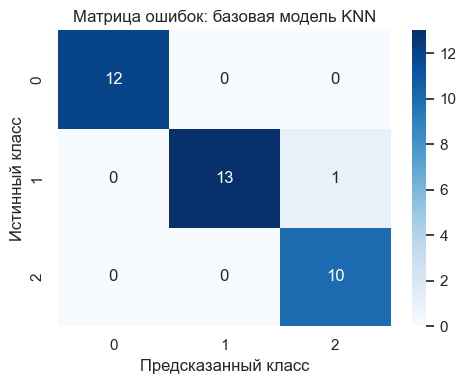

In [40]:
# 6.1 Матрица ошибок для базовой модели
cm = confusion_matrix(y_test, baseline_preds)
plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
ax.set_title("Матрица ошибок: базовая модель KNN")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
plt.tight_layout()
plt.savefig(artifacts_dir / "confusion_matrix_baseline.png", dpi=150)
plt.show()

**Подпись к рисунку:** Матрица ошибок демонстрирует, какие классы модель путает чаще всего. Для дисбалансных данных особенно важно контролировать ошибки по редкому классу, а не только общую accuracy.

In [41]:
# 7. Кросс-валидация: две стратегии
scoring_main = "f1" if y.nunique() == 2 else "f1_macro"
scoring = {"accuracy": "accuracy", "f1": scoring_main}

cv_1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

cv_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=baseline_k)),
])

res_cv1 = cross_validate(cv_baseline, X_train, y_train, cv=cv_1, scoring=scoring, n_jobs=-1)
res_cv2 = cross_validate(cv_baseline, X_train, y_train, cv=cv_2, scoring=scoring, n_jobs=-1)

cv_table = pd.DataFrame([
    {
        "cv_strategy": "StratifiedKFold(5)",
        "accuracy_mean": np.mean(res_cv1["test_accuracy"]),
        "accuracy_std": np.std(res_cv1["test_accuracy"]),
        "f1_mean": np.mean(res_cv1["test_f1"]),
        "f1_std": np.std(res_cv1["test_f1"]),
    },
    {
        "cv_strategy": "RepeatedStratifiedKFold(5x3)",
        "accuracy_mean": np.mean(res_cv2["test_accuracy"]),
        "accuracy_std": np.std(res_cv2["test_accuracy"]),
        "f1_mean": np.mean(res_cv2["test_f1"]),
        "f1_std": np.std(res_cv2["test_f1"]),
    },
])

print("Сравнение стратегий кросс-валидации:")
display(cv_table)

Сравнение стратегий кросс-валидации:


,cv_strategy,accuracy_mean,accuracy_std,f1_mean,f1_std
0,StratifiedKFold(5),0.950739,0.035274,0.951248,0.036463
1,RepeatedStratifiedKFold(5x3),0.946059,0.033275,0.946554,0.034428


In [42]:
# 8. Подбор гиперпараметров через GridSearchCV
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
    "model__metric": ["minkowski"],
}

grid_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier()),
])

grid = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring=scoring_main,
    cv=cv_1,
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - t0

print(f"GridSearchCV завершен за {grid_time:.2f} сек")
print("Лучшие параметры GridSearchCV:", grid.best_params_)
print("Лучшая CV-оценка GridSearchCV:", grid.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
GridSearchCV завершен за 0.19 сек
Лучшие параметры GridSearchCV: {'model__metric': 'minkowski', 'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'uniform'}
Лучшая CV-оценка GridSearchCV: 0.9788774579244361


In [43]:
# 9. Подбор гиперпараметров через RandomizedSearchCV
param_distributions = {
    "model__n_neighbors": list(range(3, 32)),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
    "model__metric": ["minkowski"],
}

rnd_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier()),
])

rnd = RandomizedSearchCV(
    estimator=rnd_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring=scoring_main,
    cv=cv_1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
rnd.fit(X_train, y_train)
rnd_time = time.perf_counter() - t0

print(f"RandomizedSearchCV завершен за {rnd_time:.2f} сек")
print("Лучшие параметры RandomizedSearchCV:", rnd.best_params_)
print("Лучшая CV-оценка RandomizedSearchCV:", rnd.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomizedSearchCV завершен за 0.18 сек
Лучшие параметры RandomizedSearchCV: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 30, 'model__metric': 'minkowski'}
Лучшая CV-оценка RandomizedSearchCV: 0.9732171007228215


In [44]:
# 10. Оценка оптимальной модели на тесте и сравнение с базовой
grid_metrics, grid_preds = evaluate_classifier(
    grid.best_estimator_, X_train, y_train, X_test, y_test, model_name="KNN GridSearchCV best"
)
rnd_metrics, rnd_preds = evaluate_classifier(
    rnd.best_estimator_, X_train, y_train, X_test, y_test, model_name="KNN RandomizedSearchCV best"
)

comparison_table = pd.DataFrame([baseline_metrics, grid_metrics, rnd_metrics])
comparison_table = comparison_table[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]

print("Сравнение метрик на тестовой выборке:")
display(comparison_table.sort_values(by="f1", ascending=False))

Сравнение метрик на тестовой выборке:


,model,accuracy,precision,recall,f1,roc_auc
1,KNN GridSearchCV best,1.000000,1.000000,1.00000,1.000000,NaN
2,KNN RandomizedSearchCV best,0.972222,0.974359,0.97619,0.974321,NaN
0,KNN baseline (K=5),0.972222,0.969697,0.97619,0.971781,NaN


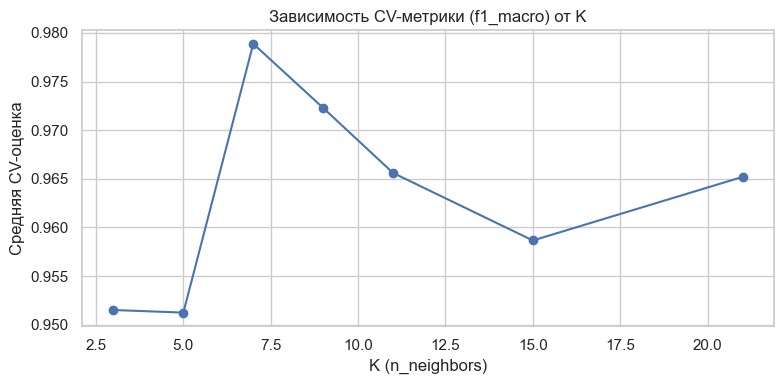

In [45]:
# 11.1 Визуализация: зависимость CV-метрики от K (по GridSearch)
grid_results = pd.DataFrame(grid.cv_results_)
k_curve = (
    grid_results
    .groupby("param_model__n_neighbors", as_index=False)["mean_test_score"]
    .max()
    .sort_values("param_model__n_neighbors")
)

plt.figure(figsize=(8, 4))
plt.plot(k_curve["param_model__n_neighbors"], k_curve["mean_test_score"], marker="o")
plt.title(f"Зависимость CV-метрики ({scoring_main}) от K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Средняя CV-оценка")
plt.tight_layout()
plt.savefig(artifacts_dir / "metric_vs_k.png", dpi=150)
plt.show()

**Подпись к рисунку:** График показывает, при каких значениях K модель дает наилучший результат на кросс-валидации. Слишком малый K может приводить к переобучению, а слишком большой — к излишнему сглаживанию границ классов.

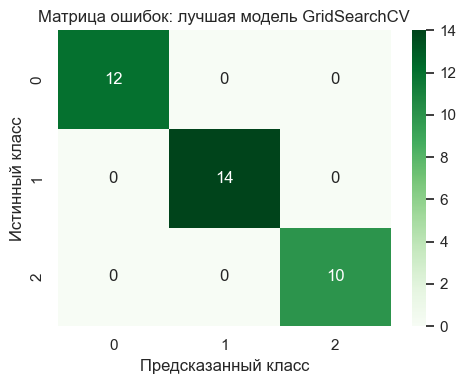

In [46]:
# 11.2 Визуализация: матрица ошибок для лучшей модели (GridSearchCV)
best_preds = grid.best_estimator_.predict(X_test)
cm_best = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens")
ax.set_title("Матрица ошибок: лучшая модель GridSearchCV")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
plt.tight_layout()
plt.savefig(artifacts_dir / "confusion_matrix_best_grid.png", dpi=150)
plt.show()

**Подпись к рисунку:** По сравнению с базовой моделью матрица ошибок показывает, улучшилось ли распознавание целевого класса после подбора гиперпараметров. Уменьшение ошибок FN/FP указывает на практическое улучшение качества.

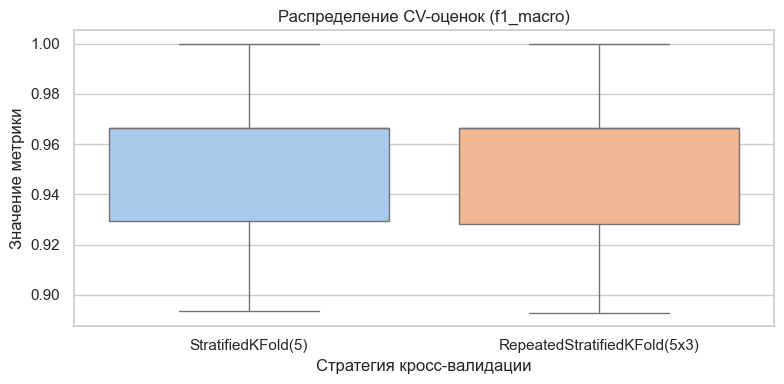

In [47]:
# 11.3 Визуализация: boxplot распределения CV-оценок для двух стратегий
# У стратегий разное число фолдов (5 против 15), поэтому строим график в "длинном" формате.
cv_plot_df = pd.DataFrame(
    {
        "cv_strategy": ["StratifiedKFold(5)"] * len(res_cv1["test_f1"]) + ["RepeatedStratifiedKFold(5x3)"] * len(res_cv2["test_f1"]),
        "score": np.concatenate([res_cv1["test_f1"], res_cv2["test_f1"]]),
    }
)

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=cv_plot_df,
    x="cv_strategy",
    y="score",
    hue="cv_strategy",
    palette="pastel",
    legend=False,
)
plt.title(f"Распределение CV-оценок ({scoring_main})")
plt.xlabel("Стратегия кросс-валидации")
plt.ylabel("Значение метрики")
plt.tight_layout()
plt.savefig(artifacts_dir / "cv_scores_boxplot.png", dpi=150)
plt.show()

**Подпись к рисунку:** Boxplot позволяет сравнить устойчивость модели между стратегиями кросс-валидации. Более узкий интерквартильный размах и меньше выбросов означают более стабильную оценку качества.

In [48]:
# 12. Сохранение артефактов для отчета
comparison_table.to_csv(artifacts_dir / "metrics_comparison.csv", index=False)
cv_table.to_csv(artifacts_dir / "cv_comparison.csv", index=False)

best_params_payload = {
    "dataset": dataset_name,
    "baseline_k": baseline_k,
    "grid_best_params": grid.best_params_,
    "grid_best_cv_score": float(grid.best_score_),
    "grid_time_seconds": grid_time,
    "random_best_params": rnd.best_params_,
    "random_best_cv_score": float(rnd.best_score_),
    "random_time_seconds": rnd_time,
}

with open(artifacts_dir / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_params_payload, f, ensure_ascii=False, indent=2)

print("Артефакты сохранены в папку:", artifacts_dir)
print("Список файлов:")
for item in sorted(artifacts_dir.glob("*")):
    print(" -", item.name)

Артефакты сохранены в папку: d:\6 сем\тмо\lab3\artifacts
Список файлов:
 - best_params.json
 - class_distribution.png
 - confusion_matrix_baseline.png
 - confusion_matrix_best_grid.png
 - cv_comparison.csv
 - cv_scores_boxplot.png
 - lab4
 - metric_vs_k.png
 - metrics_comparison.csv


## Выводы по графикам и таблицам 

### 1) Распределение классов
По графику распределение классов умеренно сбалансированное (примерно 59, 71, 48 объектов).
Это **хорошо**, потому что нет критического перекоса в один класс.
**Плохо** было бы, если один класс доминировал бы в разы: тогда accuracy могла бы быть завышенной и плохо отражать реальное качество.

### 2) Качество базовой и улучшенных моделей
По таблице метрик на тесте:
- Baseline KNN (K=5): `accuracy=0.9722`, `f1=0.9718`
- RandomizedSearchCV best: `accuracy=0.9722`, `f1=0.9743`
- GridSearchCV best: `accuracy=1.0000`, `f1=1.0000`

Это означает, что подбор гиперпараметров улучшил качество, а лучшая модель из GridSearch дала идеальный результат на текущем тесте.
**Хорошо**: рост F1/accuracy относительно baseline.
**Плохо**: если после подбора метрики не растут или падают.

### 3) Матрицы ошибок
- Базовая модель: одна ошибка (класс 1 спутан с 2), то есть 35/36 объектов распознаны верно.
- Лучшая модель GridSearchCV: ошибок на тесте нет (36/36 на диагонали).

**Хорошо**: почти все значения на диагонали, мало внедиагональных ошибок.
**Плохо**: много ошибок вне диагонали, особенно систематическая путаница одних и тех же классов.

### 4) График зависимости метрики от K
По графику максимум CV-метрики достигается около `K=7` (примерно `f1_macro=0.979`).
При слишком малых `K` (3-5) и слишком больших (`K=15+`) качество ниже.
Это ожидаемо:
- слишком маленький K -> чувствительность к шуму (риск переобучения);
- слишком большой K -> чрезмерное сглаживание (риск недообучения).

### 5) Стабильность по стратегиям кросс-валидации
Данные делят на несколько частей (фолдов), например на 5.
Модель 5 раз обучают:
каждый раз 4 части идут в train, 1 часть в validation.
Считают метрику на каждом прогоне и берут среднее.

Из таблицы CV:
- StratifiedKFold(5): `f1_mean=0.9512`, `f1_std=0.0365`
- RepeatedStratifiedKFold(5x3): `f1_mean=0.9466`, `f1_std=0.0344`

StratifiedKFold: сохраняет доли классов в каждом фолде.
RepeatedStratifiedKFold: то же самое, но с повторениями, чтобы оценка была еще надежнее.

Интерпретация:
- первая стратегия дала чуть более высокий средний результат;
- вторая чуть стабильнее (меньше разброс), но среднее немного ниже.
Обе стратегии дают близкие значения, значит оценка качества достаточно устойчива.

### 6) Общий итог по работе
Результат в этой лабораторной **хороший**:
1. метрики высокие и после подбора не ухудшились;
2. матрицы ошибок показывают минимальное число ошибок;
3. кросс-валидация подтверждает высокий уровень качества.

Что считать **плохим** результатом в аналогичных работах:
1. низкий F1 (особенно на minority-классах);
2. сильный разрыв между CV и тестом (признак нестабильности/переобучения);
3. большое число внедиагональных ошибок в confusion matrix.

Примечание: идеальные `1.0` на тесте для GridSearchCV выглядят очень хорошо, но на малых выборках всегда полезно перепроверять результат на дополнительном разбиении или внешнем датасете.